## Import Libraries

In [3]:
import os
import librosa
import numpy as np
from pathlib import Path
import zipfile
import requests
from tqdm import tqdm
import soundfile as sf
import json
import time
import logging
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up plotting
plt.style.use('default')
sns.set_palette('husl')

print(f"librosa version: {librosa.__version__}")

librosa version: 0.11.0


## Configuration and Directory Setup

In [ ]:
class AudioConfig:
    Audio_Sample_Rate = 16000
    Audio_Duration = 6
    Audio_N_Mfcc = 20
    Audio_Hop_Length = 512
    Audio_N_FFT = 2048
    Audio_N_MELS = 128

config = AudioConfig()

# Set up directories
base_dir = Path('./multimodal_mental_health_data') 
raw_audio_dir = base_dir / 'raw_audio'
processed_audio_dir = base_dir / 'processed_audio'
metadata_dir = base_dir / 'metadata'

# Create directories
for directory in [raw_audio_dir, processed_audio_dir, metadata_dir]:
    directory.mkdir(parents=True, exist_ok=True)
    print(f"Created/Verified: {directory}")

# RAVDESS_Emotions mappinf for experiments

ravdess_emotion = {
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'
}

print(f"Emotion Categories: {list(ravdess_emotion.values())}")
print(f"Current Config - sr: {config.Audio_Sample_Rate}Hz, duration: {config.Audio_Duration}s")

Created/Verified: multimodal_mental_health_data/raw_audio
Created/Verified: multimodal_mental_health_data/processed_audio
Created/Verified: multimodal_mental_health_data/metadata
Emotion Categories: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
Current Config - sr: 16000Hz, duration: 6s


### Setup Logging

In [5]:
def get_project_logger(name):
    logger = logging.getLogger(name)
    if not logger.hasHandlers():
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)
        logger.setLevel(logging.INFO)
    return logger

logger = get_project_logger('audio_collector')

print(f"Emotion Categories: {list(ravdess_emotion.values())}")
print(f"Current Config - sr: {config.Audio_Sample_Rate}Hz, duration: {config.Audio_Duration}s")
print(f"Base directory: {base_dir}")

Emotion Categories: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
Current Config - sr: 16000Hz, duration: 6s
Base directory: multimodal_mental_health_data


## Manual RAVDESS dataset setup and verification

In [6]:
print(f"Manual ravdess dataset setup")

def setup_manual_ravdess():
    ravdess_path = raw_audio_dir / 'RAVDESS'
    if not ravdess_path.exists():
        logger.error(f"RAVDESS directory not found at {ravdess_path}. Please download and extract manually.")
        return False
    
    audio_files = list(ravdess_path.glob('**/*.wav'))

    if not audio_files:
        logger.error(f"No audio files found in {ravdess_path}. Please check the extraction.")
        return False
    
    print(f"Found {len(audio_files)} audio files in RAVDESS dataset.")

    # Checking directory structure
    actors = list(ravdess_path.glob('Actor_*'))
    if actors:
        print(f"Found {len(actors)} actors in the dataset.")
        for i, actor_dir in enumerate(sorted(actors)[:5]):
            files_count = len(list(actor_dir.glob('*.wav')))
            print(f"{actor_dir.name}: {files_count} files")
        if len(actors) > 5:
            print(f" ... and {len(actors) - 5} more actors.")
    else:
        print("No actor directories found. Please check the dataset structure.")
    
    return audio_files

Manual ravdess dataset setup


In [7]:
audio_files = setup_manual_ravdess()

if audio_files:
    print(f"Success! Ready to process {len(audio_files)} ravdess files.")
    ravdess_ready = True
    datset_path = raw_audio_dir / 'RAVDESS'
else:
    print(f"Please set up the RAVDESS dataset manually as per instructions.")
    ravdess_ready = False


Found 1440 audio files in RAVDESS dataset.
Found 24 actors in the dataset.
Actor_01: 60 files
Actor_02: 60 files
Actor_03: 60 files
Actor_04: 60 files
Actor_05: 60 files
 ... and 19 more actors.
Success! Ready to process 1440 ravdess files.


## Filename Parsing

In [8]:
def parse_ravdess_filename(filename_str):
    # Ravdess format: Modality-Voice-Emotion-Intensity-Statement-Repetition-Actor.wav
    parts = filename_str.replace('.wav', '').split('-')
    if len(parts) != 7:
        return None
    
    return {
        'modality': parts[0],
        'vocal_channel': parts[1],
        'emotion_code': int(parts[2]),
        'emotion': ravdess_emotion.get(int(parts[2]), 'unknown'),
        'intensity': int(parts[3]),
        'statement': parts[4],
        'repetition': parts[5],
        'actor': int(parts[6])
    }

# Testing filenames
test_filenames = [
    "03-01-06-01-02-01-12.wav",  # fearful
    "03-01-03-02-01-01-01.wav",  # happy
    "03-01-05-01-01-02-07.wav",  # angry
    "03-01-01-01-01-01-15.wav"   # neutral
]

print("Testing ravdess filename:")
for filename in test_filenames:
    parsed = parse_ravdess_filename(filename)
    print(f"File: {filename}")
    print(f"  → Emotion: {parsed['emotion']} (code: {parsed['emotion_code']})")
    print(f"  → Actor: {parsed['actor']}, Intensity: {parsed['intensity']}")
    print()

Testing ravdess filename:
File: 03-01-06-01-02-01-12.wav
  → Emotion: fearful (code: 6)
  → Actor: 12, Intensity: 1

File: 03-01-03-02-01-01-01.wav
  → Emotion: happy (code: 3)
  → Actor: 1, Intensity: 2

File: 03-01-05-01-01-02-07.wav
  → Emotion: angry (code: 5)
  → Actor: 7, Intensity: 1

File: 03-01-01-01-01-01-15.wav
  → Emotion: neutral (code: 1)
  → Actor: 15, Intensity: 1



## RAVDESS Dataset Analysis

In [9]:
ravdess_path = raw_audio_dir / 'RAVDESS'
audio_files = list(ravdess_path.glob('**/*.wav'))

# Parse all filenames
parsed_data = []
parse_errors = 0

for file in tqdm(audio_files, desc="Parsing filenames"):
    parsed = parse_ravdess_filename(file.name)
    if parsed:
        parsed['filepath'] = file
        parsed_data.append(parsed)
    else:
        parse_errors += 1

print(f"Dataset statistics:")
print(f"Total Files: {len(audio_files)}")
print(f"Successfully Parsed: {len(parsed_data)}")
print(f"Parse Errors: {parse_errors}")

if not parsed_data:
    print("No valid parsed data available. Please check the dataset.")


        

Parsing filenames: 100%|██████████| 1440/1440 [00:00<00:00, 627772.35it/s]

Dataset statistics:
Total Files: 1440
Successfully Parsed: 1440
Parse Errors: 0


#### Emotion distribution

In [10]:
emotion_counts = {}
for data in parsed_data:
    emotion = data['emotion']
    emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1

print(f"Emotion Distribution:")
for emotion, count in sorted(emotion_counts.items()):
    print(f"{emotion}: {count} files")

Emotion Distribution:
angry: 192 files
calm: 192 files
disgust: 192 files
fearful: 192 files
happy: 192 files
neutral: 96 files
sad: 192 files
surprised: 192 files


#### Actors distribution

In [11]:
actor_count = {}
for data in parsed_data:
    actor = data['actor']
    actor_count[actor] = actor_count.get(actor, 0) + 1

print(f"Actor Distribution:")
for actor, count in sorted(actor_count.items()):
    print(f"Actor {actor}: {count} files")
    

Actor Distribution:
Actor 1: 60 files
Actor 2: 60 files
Actor 3: 60 files
Actor 4: 60 files
Actor 5: 60 files
Actor 6: 60 files
Actor 7: 60 files
Actor 8: 60 files
Actor 9: 60 files
Actor 10: 60 files
Actor 11: 60 files
Actor 12: 60 files
Actor 13: 60 files
Actor 14: 60 files
Actor 15: 60 files
Actor 16: 60 files
Actor 17: 60 files
Actor 18: 60 files
Actor 19: 60 files
Actor 20: 60 files
Actor 21: 60 files
Actor 22: 60 files
Actor 23: 60 files
Actor 24: 60 files


#### Intensity Counts

In [12]:
intensity_count = {}
for data in parsed_data:
    intensity = data['intensity']
    intensity_count[intensity] = intensity_count.get(intensity, 0) + 1

print(f"Intenstiy Distribution:")
for intensity, count in sorted(intensity_count.items()):
    intensity_name = "Normal" if intensity == 1 else "Strong"
    print(f"{intensity} ({intensity_name}): {count} files")


Intenstiy Distribution:
1 (Normal): 768 files
2 (Strong): 672 files


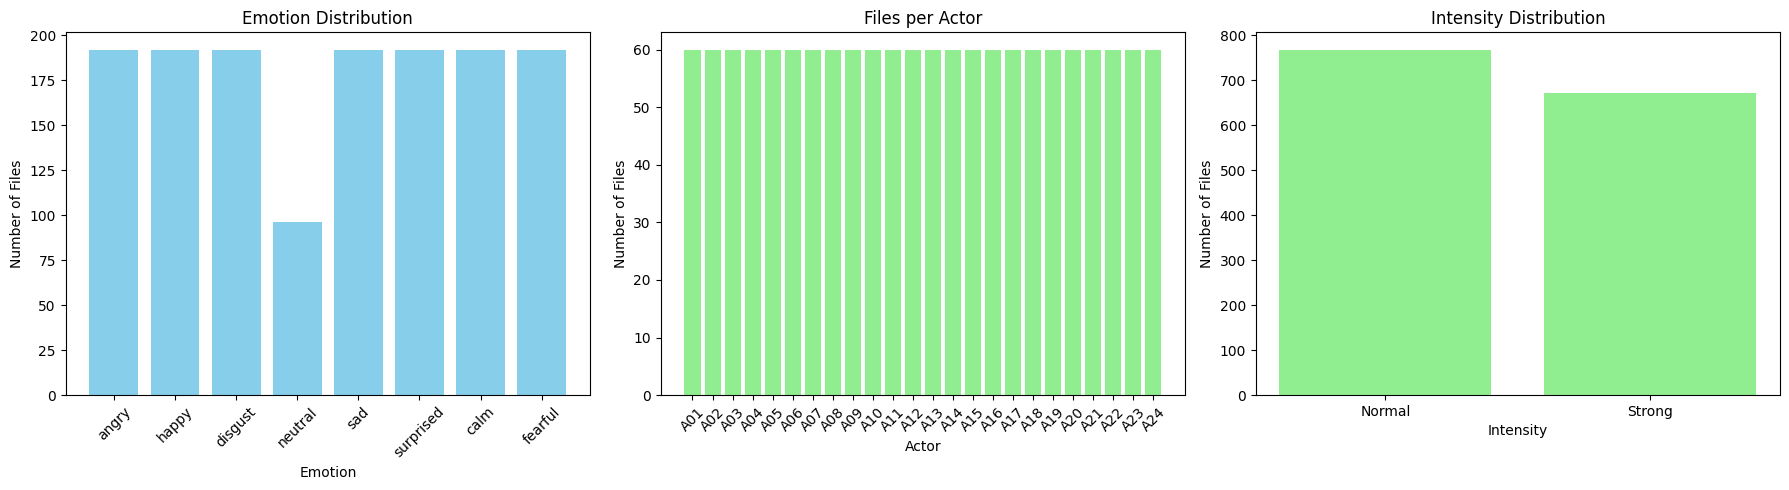

In [13]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Emotion distribution
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
axes[0].bar(emotions, counts, color='skyblue')
axes[0].set_title('Emotion Distribution')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Files')
axes[0].tick_params(axis='x', rotation=45)

# Actor distribution
actors = sorted(list(actor_count.keys()))
actor_file_counts = [actor_count[a] for a in actors]
axes[1].bar([f"A{a:02d}" for a in actors], actor_file_counts, color='lightgreen')
axes[1].set_title('Files per Actor')
axes[1].set_xlabel('Actor')
axes[1].set_ylabel('Number of Files')
axes[1].tick_params(axis='x', rotation=45)

# Intensity distribution
intensities = list(intensity_count.keys())
intensity_names = ["Normal" if i == 1 else "Strong" for i in intensities]
intensity_file_counts = list(intensity_count.values())
axes[2].bar(intensity_names, intensity_file_counts, color='lightgreen')
axes[2].set_title('Intensity Distribution')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Number of Files')
    
plt.tight_layout()
plt.show()

In [14]:
# Creating summary dataframe
import pandas as pd
df_summary = pd.DataFrame(parsed_data)



In [15]:
def analyze_ravdess_dataset():
    return {
        'total_files': len(audio_files),
        'parsed_files': len(parsed_data),
        'emotions': emotion_counts,
        'actors': actor_count,
        'intensities': intensity_count,
        'dataframe': df_summary,
        'parsed_data': parsed_data
    }

analysis_result = analyze_ravdess_dataset()

if analysis_result:
    print(f"Ready to process {analysis_result['parsed_files']} valid RAVDESS files.")

    # Storing for later use case
    RAVDESS_DATA = analysis_result['parsed_data']
    RAVDESS_DF = analysis_result['dataframe']

else:
    print('Analysis failed.')


Ready to process 1440 valid RAVDESS files.


### Single audio feature extraction experiment

In [16]:
def extract_single_audio_feature(file_path, show_plots=True):
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=config.Audio_Sample_Rate)
        print(f"Loaded: {file_path.name}")
        print(f"Duration: {len(y)/sr:.2f}s, Sample Rate: {sr}Hz")

        # Trim silence
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)

        # Ensure consistent duration
        target_length = int(config.Audio_Duration * sr)
        if len(y_trimmed) > target_length:
            y_trimmed = y_trimmed[:target_length]
        else:
            y_trimmed = np.pad(y_trimmed, (0, target_length - len(y_trimmed)))

        features = {}

        # MFCC features
        mfcc = librosa.feature.mfcc(
            y = y_trimmed, sr=sr,
            n_mfcc = config.Audio_N_Mfcc,
            hop_length = config.Audio_Hop_Length,
            n_fft = config.Audio_N_FFT
        )
        features['mfcc'] = mfcc
        features['mfcc_mean'] = np.mean(mfcc, axis=1)
        features['mfcc_var'] = np.var(mfcc, axis=1)
        features['mfcc_std'] = np.std(mfcc, axis=1) 

        # Chroma features
        chroma = librosa.feature.chroma_stft(
            y = y_trimmed, sr=sr,
            hop_length = config.Audio_Hop_Length,
            n_fft = config.Audio_N_FFT
        )
        features['chroma'] = chroma
        features['chroma_mean'] = np.mean(chroma, axis=1)

        # Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y = y_trimmed, sr=sr,
            n_mels = config.Audio_N_MELS,
            hop_length = config.Audio_Hop_Length,
            n_fft = config.Audio_N_FFT
        )
        features['mel_spectrogram'] = librosa.power_to_db(mel_spec)

        # Spectral features
        features['spectral_centroid'] = librosa.feature.spectral_centroid(y=y_trimmed, sr=sr)[0]
        features['spectral_rolloff'] = librosa.feature.spectral_rolloff(y=y_trimmed, sr=sr)[0]
        features['spectral_bandwidth'] = librosa.feature.spectral_bandwidth(y=y_trimmed, sr=sr)[0]
        features['zero_crossing_rate'] = librosa.feature.zero_crossing_rate(y_trimmed)[0]

        # Rhythm features
        tempo, _ = librosa.beat.beat_track(y=y_trimmed, sr=sr)
        features['tempo'] = float(tempo)

        # Root mean square energy
        features['rms'] = librosa.feature.rms(y=y_trimmed)[0]

        if show_plots:
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))

            # Waveform
            axes[0, 0].plot(y_trimmed)
            axes[0, 0].set_title('Waveform')
            axes[0, 0].set_xlabel('Samples')

            # MFCC
            librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[0, 1])
            axes[0, 1].set_title('MFCC Features')

            # Mel Spectrogram
            librosa.display.specshow(features['mel_spectrogram'], x_axis='time', y_axis='mel', sr=sr, ax=axes[0, 2])
            axes[0, 2].set_title('Mel Spectrogram')

            # Spectral Centroid
            axes[1, 0].plot(features['spectral_centroid'])
            axes[1, 0].set_title('Spectral Centroid')
            axes[1, 0].set_xlabel('Time Frame')

            # Zero crossing rate
            axes[1, 1].plot(features['zero_crossing_rate'])
            axes[1, 1].set_title('Zero Crossing Rate')
            axes[1, 1].set_xlabel('Time Frame')

            # RMS energy
            axes[1, 2].plot(features['rms'])
            axes[1, 2].set_title('RMS Energy')
            axes[1, 2].set_xlabel('Time Frame')

            plt.tight_layout()
            plt.show()

        return features, y_trimmed
    
    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")
        return None, None
            

Testing feature extraction on sample file: 03-01-05-01-01-02-21.wav (Emotion: angry)
Loaded: 03-01-05-01-01-02-21.wav
Duration: 4.00s, Sample Rate: 16000Hz


/tmp/ipykernel_1044/818984173.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


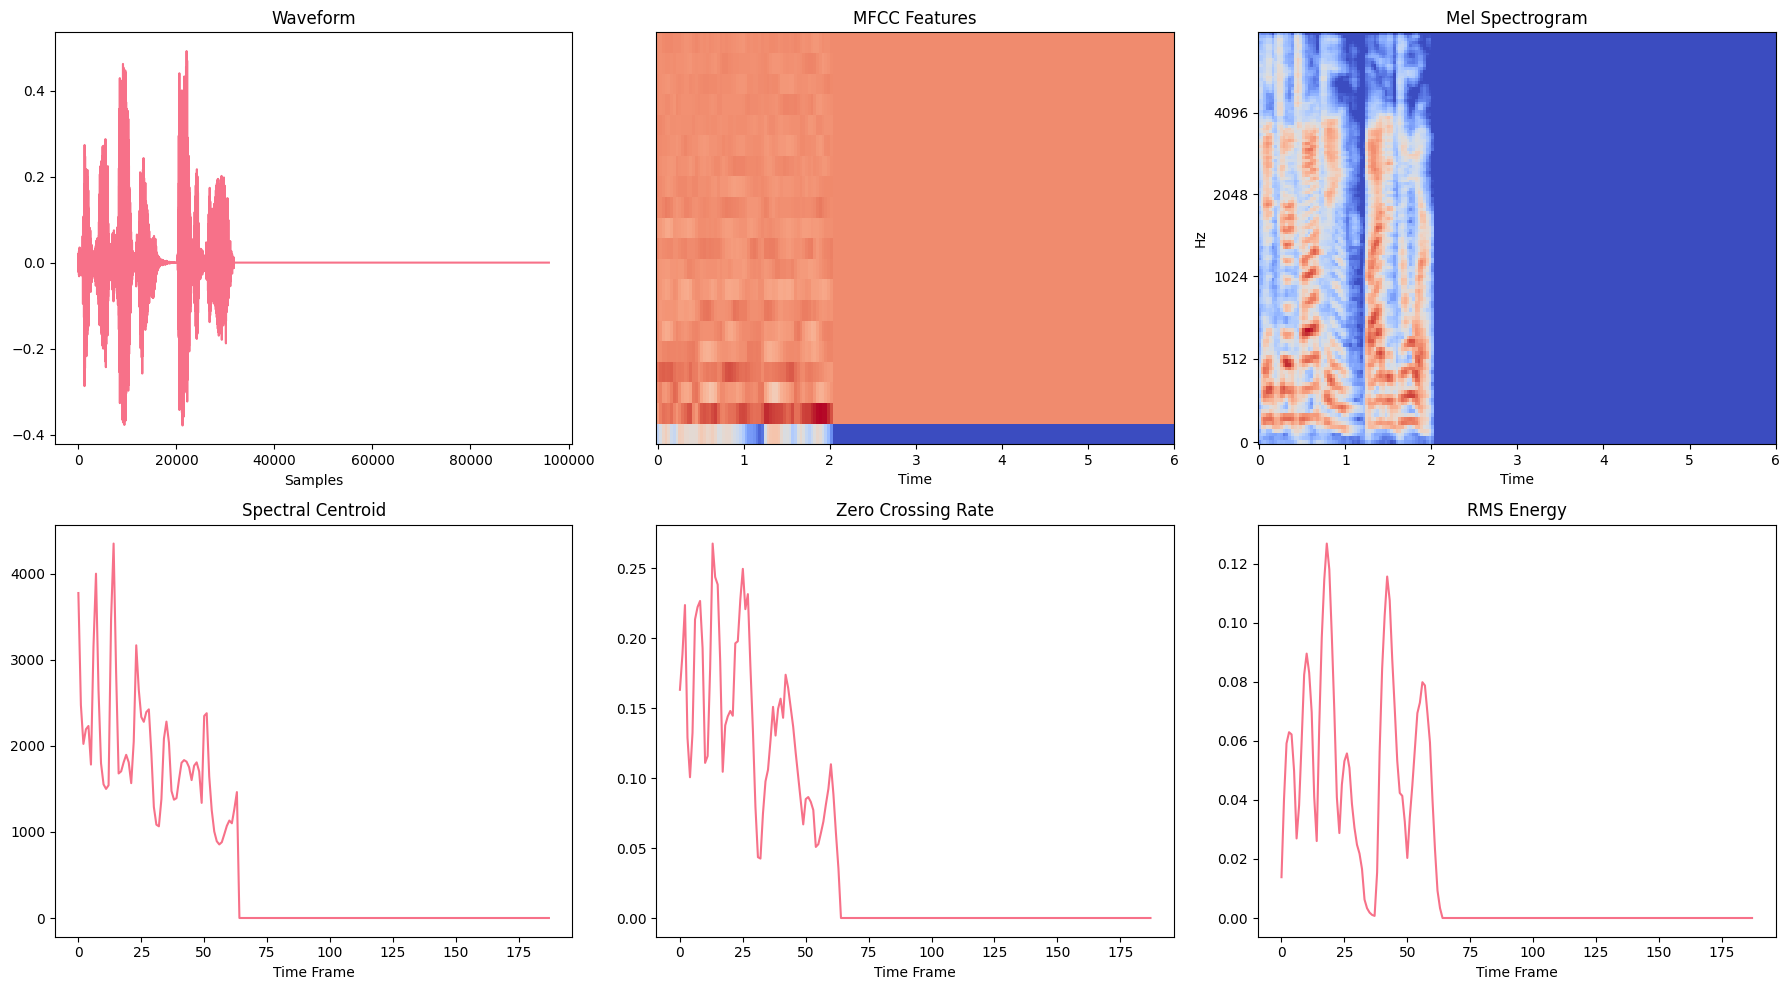

Extracted features summary:
MFCC shape: (20, 188)
MFCC mean: [-507.1837     26.850157  -10.432482   12.365963   -5.159049]...
Tempo: 156.2 BPM
Avg Spectral Centroid: 648.20 Hz
Avg Zero Crossing Rate: 0.0467


In [17]:
# Testing feature extraction on a sample file
sample_file = RAVDESS_DATA[0]['filepath']
sample_emotion = RAVDESS_DATA[0]['emotion']

print(f"Testing feature extraction on sample file: {sample_file.name} (Emotion: {sample_emotion})")
features, audio = extract_single_audio_feature(sample_file)

if features:
    print(f"Extracted features summary:")
    print(f"MFCC shape: {features['mfcc'].shape}")
    print(f"MFCC mean: {features['mfcc_mean'][:5]}...") # first 5 coefficient
    print(f"Tempo: {features['tempo']:.1f} BPM")
    print(f"Avg Spectral Centroid: {np.mean(features['spectral_centroid']):.2f} Hz")
    print(f"Avg Zero Crossing Rate: {np.mean(features['zero_crossing_rate']):.4f}")
else:
    print("Feature extraction failed.")

### Batch Feature extraction experiment

In [18]:
# processing multiple files and comparing feature across emotions
def process_multiple_ravdess_files(sample_size=5):
    if not RAVDESS_DATA:
        print("No RAVDESS data available!")
        return None
        
    # sample files from each emotion
    emotion_samples = {}
    for data in RAVDESS_DATA:
        if not isinstance(data, dict) or 'emotion' not in data:
            print(f"Invalid data format: {data}")
            continue
            
        emotion = data['emotion']
        if emotion not in emotion_samples:
            emotion_samples[emotion] = []
        if len(emotion_samples[emotion]) < sample_size:
            if 'filepath' not in data:
                print(f"Missing filepath in data: {data}")
                continue
            if not data['filepath'].exists():
                print(f"File does not exist: {data['filepath']}")
                continue
            emotion_samples[emotion].append(data)

    if not emotion_samples:
        print("No valid samples found!")
        return None

    print(f"Found samples for emotions: {list(emotion_samples.keys())}")
    all_features = {}

    for emotion, samples in emotion_samples.items():
        print(f"\nProcessing {emotion} samples ({len(samples)} files)...")
        emotion_features = []

        for sample in samples:
            try:
                print(f"Processing file: {sample['filepath'].name}")
                features, audio = extract_single_audio_feature(sample['filepath'], show_plots=False)
                if features is not None:
                    # Calculate std if not present but mfcc exists
                    if 'mfcc' in features and 'mfcc_std' not in features:
                        features['mfcc_std'] = np.std(features['mfcc'], axis=1)
                    
                    features['emotion'] = emotion
                    features['actor'] = sample['actor']
                    features['intensity'] = sample['intensity']
                    emotion_features.append(features)
                    print(f"✓ Successfully extracted features")
            except Exception as e:
                print(f"✗ Error processing {sample['filepath'].name}: {str(e)}")
                continue

        if emotion_features:
            all_features[emotion] = emotion_features
            print(f"Added {len(emotion_features)} feature sets for {emotion}")
        else:
            print(f"No features extracted for {emotion}")

    return all_features

# Test with a very small sample first
print("\nTesting with 2 samples per emotion:")
batch_features = process_multiple_ravdess_files(sample_size=2)

# Process the features
if batch_features:
    comparison_data = []
    
    for emotion, features_list in batch_features.items():
        print(f"\nProcessing {len(features_list)} features for {emotion}")
        
        for features in features_list:
            try:
                # Verify all required keys exist
                required_keys = ['actor', 'tempo', 'spectral_centroid', 'zero_crossing_rate', 
                               'rms', 'mfcc_mean']
                missing_keys = [key for key in required_keys if key not in features]
                
                if missing_keys:
                    print(f"Missing keys for {emotion}: {missing_keys}")
                    print(f"Available keys: {list(features.keys())}")
                    continue
                
                # Create row with more flexible feature handling
                row = {
                    'emotion': emotion,
                    'actor': features['actor'],
                    'tempo': float(features['tempo']),  # Explicit float conversion
                    'avg_spectral_centroid': float(np.mean(features['spectral_centroid'])),
                    'avg_zero_crossing_rate': float(np.mean(features['zero_crossing_rate'])),
                    'avg_rms': float(np.mean(features['rms'])),
                    'mfcc_1_mean': float(features['mfcc_mean'][0]),
                    'mfcc_2_mean': float(features['mfcc_mean'][1])
                }
                
                # Add std features if available
                if 'mfcc_std' in features:
                    row['mfcc_1_std'] = float(features['mfcc_std'][0])
                
                comparison_data.append(row)
                print(f"✓ Added features for {emotion}, actor {features['actor']}")
                
            except Exception as e:
                print(f"✗ Error creating row for {emotion}: {str(e)}")
                print(f"Feature keys available: {list(features.keys())}")
                continue

    if comparison_data:
        df_comparison = pd.DataFrame(comparison_data)
        print("\nSuccessfully created DataFrame!")
        print(f"Shape: {df_comparison.shape}")
        print("\nFirst few rows:")
        print(df_comparison.head())
    else:
        print("\nNo comparison data generated!")
else:
    print("Batch processing failed.")


Testing with 2 samples per emotion:
Found samples for emotions: ['angry', 'happy', 'disgust', 'neutral', 'sad', 'surprised', 'calm', 'fearful']

Processing angry samples (2 files)...
Processing file: 03-01-05-01-01-02-21.wav
Loaded: 03-01-05-01-01-02-21.wav
Duration: 4.00s, Sample Rate: 16000Hz


/tmp/ipykernel_1044/818984173.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


✓ Successfully extracted features
Processing file: 03-01-05-02-01-02-21.wav
Loaded: 03-01-05-02-01-02-21.wav
Duration: 4.47s, Sample Rate: 16000Hz
✓ Successfully extracted features
Added 2 feature sets for angry

Processing happy samples (2 files)...
Processing file: 03-01-03-01-01-02-21.wav
Loaded: 03-01-03-01-01-02-21.wav
Duration: 3.80s, Sample Rate: 16000Hz
✓ Successfully extracted features
Processing file: 03-01-03-01-02-01-21.wav
Loaded: 03-01-03-01-02-01-21.wav
Duration: 3.70s, Sample Rate: 16000Hz
✓ Successfully extracted features
Added 2 feature sets for happy

Processing disgust samples (2 files)...
Processing file: 03-01-07-02-01-02-21.wav
Loaded: 03-01-07-02-01-02-21.wav
Duration: 4.04s, Sample Rate: 16000Hz
✓ Successfully extracted features
Processing file: 03-01-07-02-01-01-21.wav
Loaded: 03-01-07-02-01-01-21.wav
Duration: 4.07s, Sample Rate: 16000Hz
✓ Successfully extracted features
Added 2 feature sets for disgust

Processing neutral samples (2 files)...
Processing file

In [19]:
# Store for visualization
BATCH_COMPARISION_DF = df_comparison
print(f"Processed {len(comparison_data)} samples across {len(batch_features)} emotions.")

Processed 16 samples across 8 emotions.


### Feature Visualization Experiment

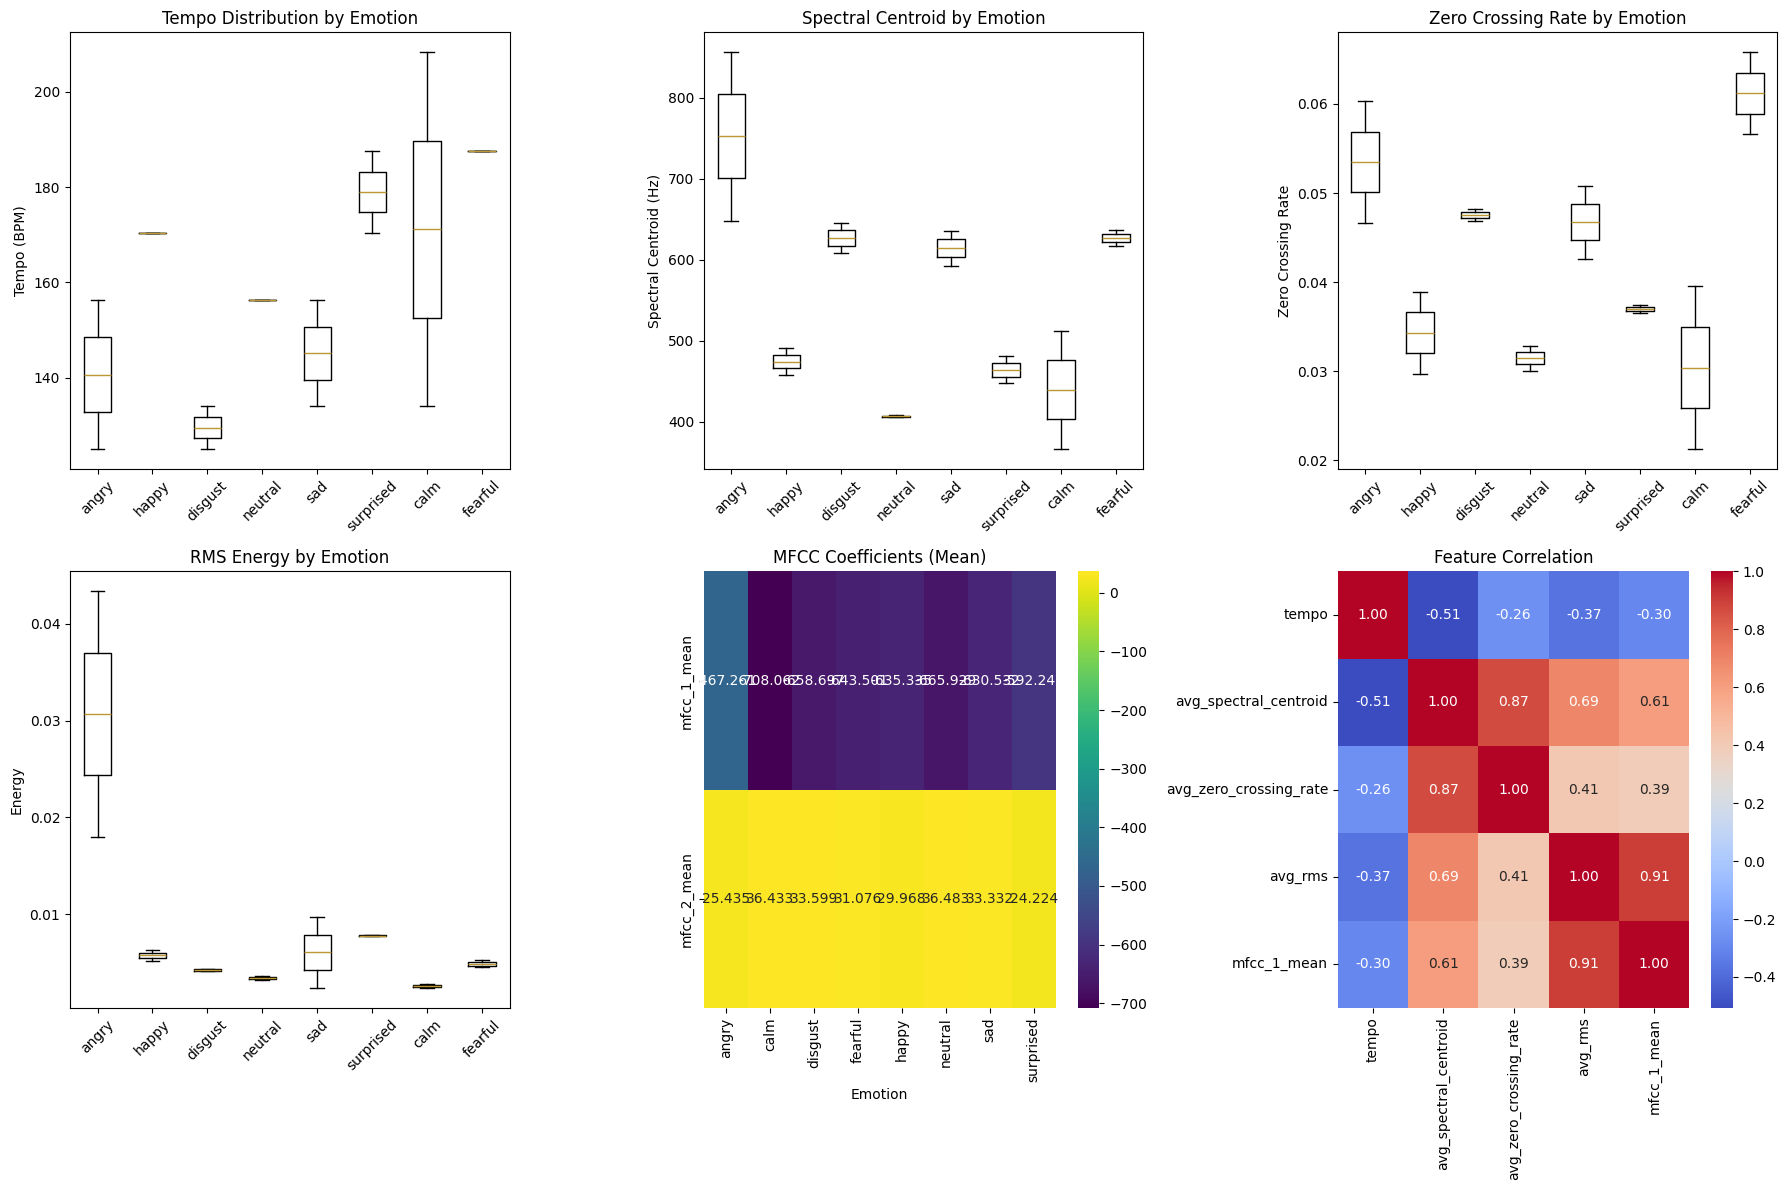

In [20]:
df = BATCH_COMPARISION_DF
emotions =df['emotion'].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Tempo comparison
tempo_data = [df[df['emotion'] == emotion]['tempo'].values for emotion in emotions]
axes[0, 0].boxplot(tempo_data, tick_labels=emotions)
axes[0, 0].set_title('Tempo Distribution by Emotion')
axes[0, 0].set_ylabel('Tempo (BPM)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Spectral Centroid comparison
centroid_data = [df[df['emotion'] == emotion]['avg_spectral_centroid'].values for emotion in emotions]
axes[0, 1].boxplot(centroid_data, tick_labels=emotions)
axes[0, 1].set_title('Spectral Centroid by Emotion')
axes[0, 1].set_ylabel('Spectral Centroid (Hz)')
axes[0, 1].tick_params(axis='x', rotation=45)   

# Zero Crossing Rate comparison
zcr_data = [df[df['emotion'] == emotion]['avg_zero_crossing_rate'].values for emotion in emotions]
axes[0, 2].boxplot(zcr_data, tick_labels=emotions)
axes[0, 2].set_title('Zero Crossing Rate by Emotion')
axes[0, 2].set_ylabel('Zero Crossing Rate')
axes[0, 2].tick_params(axis='x', rotation=45)   

# RMS Energy
rms_data = [df[df['emotion'] == emotion]['avg_rms'].values for emotion in emotions]
axes[1,0].boxplot(rms_data, tick_labels=emotions)
axes[1,0].set_title('RMS Energy by Emotion')
axes[1,0].set_ylabel('Energy')
axes[1,0].tick_params(axis='x', rotation=45)

# MFCC coefficients heatmap
mfcc_summary = df.groupby('emotion')[['mfcc_1_mean', 'mfcc_2_mean']].mean()
sns.heatmap(mfcc_summary.T, annot=True, fmt='.3f', cmap='viridis', ax=axes[1,1])
axes[1,1].set_title('MFCC Coefficients (Mean)')
axes[1,1].set_xlabel('Emotion')

# Feature correlation
numeric_cols = ['tempo', 'avg_spectral_centroid', 'avg_zero_crossing_rate', 'avg_rms', 'mfcc_1_mean']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1, 2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

In [21]:
print("Feature analysis insights:")

# finding emotion with hightest/lowest for each feature
feature_stats = df.groupby('emotion').mean()

print(f"Highest tempo: {feature_stats['tempo'].idxmax()} ({feature_stats['tempo'].max():.1f} BPM)")
print(f"Lowest tempo: {feature_stats['tempo'].idxmin()} ({feature_stats['tempo'].min():.1f} BPM)")
    
print(f"Highest spectral centroid: {feature_stats['avg_spectral_centroid'].idxmax()} ({feature_stats['avg_spectral_centroid'].max():.1f} Hz)")
print(f"Lowest spectral centroid: {feature_stats['avg_spectral_centroid'].idxmin()} ({feature_stats['avg_spectral_centroid'].min():.1f} Hz)")
    
print(f"Highest zero crossing rate: {feature_stats['avg_zero_crossing_rate'].idxmax()} ({feature_stats['avg_zero_crossing_rate'].max():.4f})")
print(f"Highest RMS energy: {feature_stats['avg_rms'].idxmax()} ({feature_stats['avg_rms'].max():.4f})")

Feature analysis insights:
Highest tempo: fearful (187.5 BPM)
Lowest tempo: disgust (129.5 BPM)
Highest spectral centroid: angry (752.2 Hz)
Lowest spectral centroid: neutral (406.7 Hz)
Highest zero crossing rate: fearful (0.0612)
Highest RMS energy: angry (0.0307)


### Parameter tuning experiment

Testing parameters with: 03-01-05-01-01-02-21.wav
Standard (13) - Shape: (13, 63), Mean: -22.14, Std: 83.94
Extended (20) - Shape: (20, 63), Mean: -16.76, Std: 68.25
Detailed (40) - Shape: (40, 63), Mean: -10.31, Std: 49.21


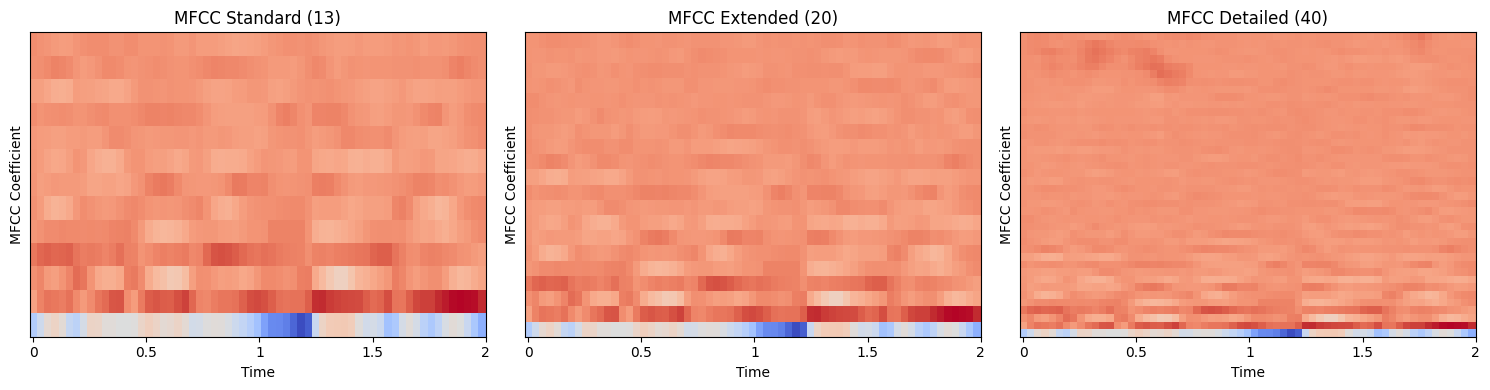


 Testing different hop lengths:
Hop length 256: Shape=(20, 125), Time resolution=125 frames
Hop length 512: Shape=(20, 63), Time resolution=63 frames
Hop length 1024: Shape=(20, 32), Time resolution=32 frames

 Parameter Recommendations:
-Use 13 MFCCs for speed, 20+ for better accuracy.
-Hop length 512 provides good balance.
-Current config: 20 MFCCs, 512 hop length.


In [22]:
# experiment with different MFCC parameters
def compare_feature_parameters(audio_file):
    y, sr = librosa.load(audio_file, sr=config.Audio_Sample_Rate)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)

    # test different MFCC parameters
    mfcc_configs = [
        {'n_mfcc': 13, 'name': 'Standard (13)'},
        {'n_mfcc': 20, 'name': 'Extended (20)'},
        {'n_mfcc': 40, 'name': 'Detailed (40)'}
    ]

    fig, axes = plt.subplots(1, len(mfcc_configs), figsize=(15, 4))

    results = {}
    for i, mfcc_config in enumerate(mfcc_configs):
        mfcc = librosa.feature.mfcc(
            y = y_trimmed, sr = sr,
            n_mfcc = mfcc_config['n_mfcc'],
            hop_length = config.Audio_Hop_Length,
            n_fft = config.Audio_N_FFT
        )

        librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[i])
        axes[i].set_title(f"MFCC {mfcc_config['name']}")
        axes[i].set_ylabel("MFCC Coefficient")

        results[mfcc_config['name']] = {
            'shape': mfcc.shape,
            'mean': np.mean(mfcc),
            'std': np.std(mfcc),
            'mfcc_data': mfcc
        }


        print(f"{mfcc_config['name']} - Shape: {mfcc.shape}, Mean: {np.mean(mfcc):.2f}, Std: {np.std(mfcc):.2f}")

    plt.tight_layout()
    plt.show()

    # Test different hop lengths
    print(f"\n Testing different hop lengths:")
    hop_lengths = [256, 512, 1024]

    for hop_length in hop_lengths:
        mfcc = librosa.feature.mfcc(
            y=y_trimmed, sr=sr,
            n_mfcc=20,
            hop_length=hop_length,
            n_fft=config.Audio_N_FFT
        )

        print(f"Hop length {hop_length}: Shape={mfcc.shape}, Time resolution={mfcc.shape[1]} frames")
    
    return results


sample_file = RAVDESS_DATA[0]['filepath']
print(f"Testing parameters with: {sample_file.name}")
parameters_results = compare_feature_parameters(sample_file)

print(f"\n Parameter Recommendations:")
print(f"-Use 13 MFCCs for speed, 20+ for better accuracy.")
print(f"-Hop length 512 provides good balance.")
print(f"-Current config: {config.Audio_N_Mfcc} MFCCs, {config.Audio_Hop_Length} hop length.")



### Complete Dataset Processing

In [24]:
def process_complete_ravdess_dataset():
    processed_data = []
    failed_files = []

    # Process all files
    for i, sample in enumerate(tqdm(RAVDESS_DATA, desc='Processing RAVDESS')):
        try:
            # extracting features
            features, audio_data = extract_single_audio_feature(sample['filepath'], show_plots=False)

            if features is None:
                failed_files.append(sample['filepath'].name)
                continue
                
            # Save processed audio
            output_filename = f"RAVDESS_{sample['filepath'].stem}_processed.wav"
            output_path = processed_audio_dir / output_filename
            sf.write(output_path, audio_data, config.Audio_Sample_Rate)

            # Combine metadata and features
            sample_data = {
                'file_id': sample['filepath'].stem,
                'dataset': 'RAVDESS',
                'original_path': str(sample['filepath']),
                'processed_path': str(output_path),
                'emotion': sample['emotion'],
                'emotion_code': sample['emotion_code'],
                'actor': sample['actor'],
                'intensity': sample['intensity'],
                'modality': sample['modality'],
                'vocal_channel': sample['vocal_channel'],
                'statement': sample['statement'],
                'repetition': sample['repetition'],

                # Audio features
                'tempo': float(features['tempo']),
                'mfcc_mean': features['mfcc_mean'].tolist(),
                'mfcc_std': features['mfcc_std'].tolist(),
                'chroma_mean': features['chroma_mean'].tolist(),
                'spectral_centroid_mean': float(np.mean(features['spectral_centroid'])),
                'spectral_bandwidth_mean': float(np.mean(features['spectral_bandwidth'])),
                'spectral_rolloff_mean': float(np.mean(features['spectral_rolloff'])),
                'zero_crossing_rate_mean': float(np.mean(features['zero_crossing_rate'])),
                'rms_mean': float(np.mean(features['rms'])),

                # feature shapes for visulaization
                'mfcc_shape': features['mfcc'].shape,
                'mel_spectrogram_shape': features['mel_spectrogram'].shape
            }

            processed_data.append(sample_data)\
        
        except Exception as e:
            logger.error(f"Error processing {sample['filepath'].name}: {e}")
            failed_files.append(sample['filepath'].name)

    print(f"Processed results:")
    print(f"Successfully processed {len(processed_data)} files.")
    print(f"Failed: {len(failed_files)} files")

    if failed_files:
        print(f"Failed files: {failed_files[:5]}")

    return processed_data
        
                               

In [25]:
# Running complete processing
all_processed_data = process_complete_ravdess_dataset()

if all_processed_data:
    print(f"Successfully processed {len(all_processed_data)} audio files.")
    PROCESSED_RAVDESS_DATA = all_processed_data
else:
    print("Processed failed.")

Processing RAVDESS:   0%|          | 0/1440 [00:00<?, ?it/s]

Loaded: 03-01-05-01-01-02-21.wav
Duration: 4.00s, Sample Rate: 16000Hz


/tmp/ipykernel_1044/818984173.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)
Processing RAVDESS:   0%|          | 1/1440 [00:00<10:55,  2.20it/s]

Loaded: 03-01-03-01-01-02-21.wav
Duration: 3.80s, Sample Rate: 16000Hz


Processing RAVDESS:   0%|          | 2/1440 [00:00<07:59,  3.00it/s]

...

Loaded: 03-01-05-02-01-01-04.wav
Duration: 3.77s, Sample Rate: 16000Hz


Processing RAVDESS: 100%|█████████▉| 1439/1440 [07:07<00:00,  2.26it/s]

Loaded: 03-01-01-01-02-02-04.wav
Duration: 3.24s, Sample Rate: 16000Hz


Processing RAVDESS: 100%|██████████| 1440/1440 [07:07<00:00,  3.37it/s]

Processed results:
Successfully processed 1440 files.
Failed: 0 files
Successfully processed 1440 audio files.


In [26]:
len(all_processed_data)

1440

### MetaData creation and export

In [27]:
def create_metadata():
    processed_data = PROCESSED_RAVDESS_DATA

    # Summary statistics
    summary = {
        'processing_timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'total_samples': len(processed_data),
        'dataset_info': {
            'name': 'RAVDESS',
            'description': 'Ryerson Audio-Visual Database of Emotional Speech and Song',
            'emotion': list(ravdess_emotion.values()),
            'total_emotions': len(ravdess_emotion)
        },
        'processing_config': {
            'sample_rate': config.Audio_Sample_Rate,
            'duration': config.Audio_Duration,
            'n_mfcc': config.Audio_N_Mfcc,
            'hop_length': config.Audio_Hop_Length,
            'n_fft': config.Audio_N_FFT,
            'n_mel': config.Audio_N_MELS
        },
        'statistics': {}
    }

    # count by categories
    emotion_counts = {}
    actor_counts = {}
    intensity_counts = {}

    for sample in processed_data:
        emotion = sample['emotion']
        emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1

        actor = sample['actor']
        actor_counts[actor] = actor_counts.get(actor, 0) + 1

        intensity = sample['intensity']
        intensity_counts[intensity] = intensity_counts.get(intensity, 0) + 1


    summary['statistics'] = {
        'emotions': emotion_counts,
        'actors': dict(sorted(actor_counts.items())),
        'intensities': intensity_counts,
        'feature_statistics': {
            'avg_tempo': np.mean([s['tempo'] for s in processed_data]),
            'avg_spectral_centroid': np.mean([s['spectral_centroid_mean'] for s in processed_data]),
            'avg_zero_crossing_rate': np.mean([s['zero_crossing_rate_mean'] for s in processed_data])
        }
    }

    # Saving metadata
    metadata_file = metadata_dir / 'ravdess_audio_metadata.json'
    with open(metadata_file, 'w') as f:
        json.dump({
            'summary': summary,
            'samples': processed_data
        }, f, indent=2
        )

    print(f"Metadata saved to {metadata_file}")


    # Creating feature summary CSV
    feature_rows = []
    for sample in processed_data:
        row = {
            'file_id': sample['file_id'],
            'emotion': sample['emotion'],
            'actor': sample['actor'],
            'intensity': sample['intensity'],
            'tempo': sample['tempo'],
            'spectral_centroid_mean': sample['spectral_centroid_mean'],
            'spectral_bandwidth_mean': sample['spectral_bandwidth_mean'],
            'spectral_rolloff_mean': sample['spectral_rolloff_mean'],
            'zero_crossing_rate_mean': sample['zero_crossing_rate_mean'],
            'rms_mean': sample['rms_mean']
        }

        # Adding first 13 MFCC coefficients and first 12 chroma features
        for i in range(min(13, len(sample['mfcc_mean']))):
            row[f'mfcc_{i+1}_mean'] = sample['mfcc_mean'][i]
            row[f'mfcc_{i+1}_std'] = sample['mfcc_std'][i]

        for i in range(min(12, len(sample['chroma_mean']))):
            row[f'chroma_{i+1}_mean'] = sample['chroma_mean'][i]\

        feature_rows.append(row)

    # saving as CSV
    feature_df = pd.DataFrame(feature_rows)
    csv_file = metadata_dir / 'ravdess_features_summary.csv'
    feature_df.to_csv(csv_file, index=False) 

    print(f"Shape: {feature_df.shape}")
    print(f"Columns: {list(feature_df.columns)[:10]}")

    # Saving processing summary
    processing_summary = {
        'project': 'Multimodal Mental Health AI - Audio processing',
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'dataset': 'RAVDESS',
        'total_files_processed': len(processed_data),
        'emotions_covered': list(range(min(actor_counts.keys()), max(actor_counts.keys())+1)),
        'output_files': {
            'metadata': str(metadata_file),
            'feature_csv': str(csv_file),
            'processed_audio_dir': str(processed_audio_dir)
        }
    }

    summary_file = metadata_dir / 'processing_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(processing_summary, f, indent=2)

    print(f"Processing summary saved to {summary_file}")

    return summary

In [ ]:
# Creating metadata
metadata_summary = create_metadata()

if metadata_summary:
    print("Ready for machine learning training!")
else:
    print("Error in creating metadata.")

Metadata saved to multimodal_mental_health_data/metadata/ravdess_audio_metadata.json
Shape: (1440, 48)
Columns: ['file_id', 'emotion', 'actor', 'intensity', 'tempo', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'zero_crossing_rate_mean', 'rms_mean']
Processing summary saved to multimodal_mental_health_data/metadata/processing_summary.json
Ready for machine learning training!


### Final Validation

In [29]:
df = pd.read_csv(metadata_dir / 'ravdess_features_summary.csv')
print(f"Features CSV Preview:")
print(f"Shape: {df.shape}")
print(f"Emotions: {df['emotion'].unique()}")
print("Sample rows:")
print(df[['file_id', 'emotion', 'actor', 'tempo', 'spectral_centroid_mean']].head())

Features CSV Preview:
Shape: (1440, 48)
Emotions: ['angry' 'happy' 'disgust' 'neutral' 'sad' 'surprised' 'calm' 'fearful']
Sample rows:
                file_id  emotion  actor       tempo  spectral_centroid_mean
0  03-01-05-01-01-02-21    angry     21  156.250000              648.202748
1  03-01-03-01-01-02-21    happy     21  170.454545              457.251274
2  03-01-07-02-01-02-21  disgust     21  125.000000              607.623467
3  03-01-07-02-01-01-21  disgust     21  133.928571              645.571993
4  03-01-07-01-01-01-21  disgust     21  144.230769              559.625308
